In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import sys

working_directory = Path.cwd().resolve()
PROJECT_ROOT = next(
    (path for path in (working_directory, *working_directory.parents)
     if (path / "pyproject.toml").is_file() and (path / "src").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError("Open this notebook from within the project directory.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
from src.models.moirai import Moirai2Forecaster
from src.evaluation.experiment import run_single_forecast

In [5]:
moirai = Moirai2Forecaster()

Loading Moirai-2 from Salesforce/moirai-2.0-R-small on cuda


Moirai-2 loaded
Quantiles: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


In [6]:
next(moirai.module.parameters()).device

device(type='cuda', index=0)

In [7]:
import torch
print(torch.cuda.get_device_name(0))

NVIDIA GeForce RTX 3050 Ti Laptop GPU


In [8]:
"""Test on only one window"""
from src.data.loader import load_dataset
from src.data.windows import make_last_window

dataset = load_dataset('ETTh1')
window = make_last_window(dataset=dataset, context_length=512, prediction_length=96)

print(window.history.shape)
print(window.target.shape)

(512, 7)
(96, 7)


In [9]:
forecast = moirai.predict(history=window.history, prediction_length=96)
forecast.predictions.shape

(96, 7)

In [10]:
forecast.lower.shape

(96, 7)

In [11]:
forecast.upper.shape

(96, 7)

In [12]:
import numpy as np

print(f"Finite: {np.isfinite(forecast.predictions).all()}")
print(f"Min: {forecast.predictions.min():.4f}")
print(f"Max: {forecast.predictions.max():.4f}")
print(f"Mean: {forecast.predictions.mean():.4f}")

Finite: True
Min: -17.8928
Max: 14.4686
Mean: 3.2997


In [13]:
ot_index = window.columns.index('OT')

In [14]:
window.target[:10, ot_index]

array([5.909, 5.979, 5.839, 5.839, 5.346, 5.417, 5.417, 5.768, 5.909,
       6.261], dtype=float32)

In [15]:
forecast.predictions[:10, ot_index]

array([5.517137 , 5.489585 , 5.5170574, 5.5488844, 5.5521708, 5.5766683,
       5.603652 , 5.625612 , 5.614476 , 5.5143332], dtype=float32)

In [16]:
result = run_single_forecast(
    forecaster=moirai,
    dataset_name="ETTh1",
    context_length=512,
    prediction_length=96,
    save_results=True)


Dataset: ETTh1
History shape: (512, 7)
Target shape: (96, 7)

Prediction shape matches target shape.
Forecast does not contain NaN or infinite values.

seasonal_period has been configured for MASE.
Saved:
- Forecast: results/forecasts/moirai2_ETTh1_h96.parquet
- Metrics: results/metrics/moirai2_ETTh1_h96.json


In [18]:
for key, value in result["metrics"].items():
    if key == "mase_per_variable":
        continue
    formatted_value = f"{value:.4f}" if isinstance(value, float) else value
    print(f"{key:25}: {formatted_value}")

mae                      : 1.2731
rmse                     : 1.6983
smape                    : 27.6315
mase                     : 0.9752
dataset                  : ETTh1
model                    : moirai2
context_length           : 512
prediction_length        : 96
inference_time_seconds   : 0.0661


In [19]:
if "mase_per_variable" in result["metrics"]:
    print("MASE by Variables:")
    for var_name, score in result["metrics"]["mase_per_variable"].items():
        formatted_score = f"{score:.4f}" if isinstance(score, float) else score
        print(f"{var_name:10}: {formatted_score}")

MASE by Variables:
HUFL      : 0.8470
HULL      : 1.1732
MUFL      : 0.8358
MULL      : 1.1317
LUFL      : 1.0173
LULL      : 0.7803
OT        : 1.0411


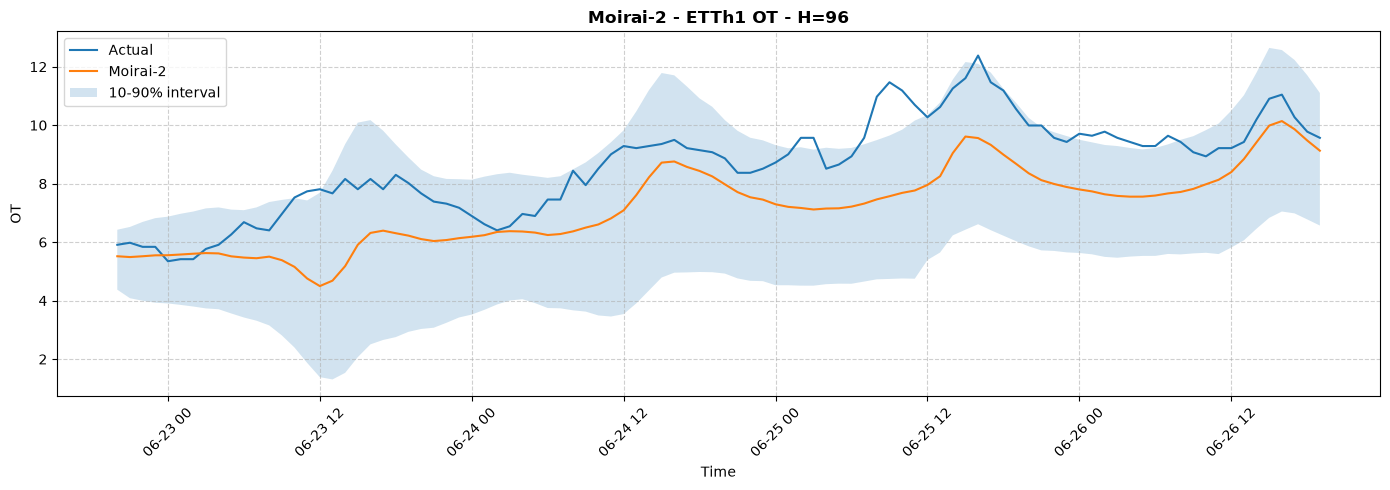

In [20]:
import matplotlib.pyplot as plt

df = result['prediction_df']
ot = df[df['variable'] == 'OT']

plt.figure(figsize=(14, 5))
plt.plot(ot["timestamp"], ot["actual"], label="Actual")
plt.plot(ot["timestamp"], ot["prediction"], label="Moirai-2")
if "lower" in ot.columns:
    plt.fill_between(ot["timestamp"], ot["lower"], ot["upper"], alpha=0.2, label="10-90% interval")

plt.title("Moirai-2 - ETTh1 OT - H=96", fontweight='bold')
plt.xlabel("Time")
plt.ylabel("OT")

plt.legend()
plt.grid(True, alpha=0.6, linestyle='--')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../../results/figures/moirai2_ETTh1_h96.png")
plt.show()

In [21]:
import json

with open("../../results/metrics/chronos2_ETTh1_h96.json") as f:
    chronos_metrics = json.load(f)

with open("../../results/metrics/moirai2_ETTh1_h96.json") as f:
    moirai_metrics = json.load(f)

In [22]:
chronos_metrics

[{'mae': 1.3032348156,
  'rmse': 1.6230419874,
  'smape': 28.301902771,
  'mase': 0.9597409368,
  'dataset': 'ETTh1',
  'model': 'chronos2',
  'context_length': 512,
  'prediction_length': 96,
  'inference_time_seconds': 0.382604,
  'mase_per_variable': {'HUFL': 0.8622621298,
   'HULL': 1.1895810366,
   'MUFL': 0.856585741,
   'MULL': 1.2031320333,
   'LUFL': 0.8077147007,
   'LULL': 0.6275508404,
   'OT': 1.1713598967}}]

In [23]:
moirai_metrics

[{'mae': 1.2730609179,
  'rmse': 1.6983413696,
  'smape': 27.6314735413,
  'mase': 0.9752120376,
  'dataset': 'ETTh1',
  'model': 'moirai2',
  'context_length': 512,
  'prediction_length': 96,
  'inference_time_seconds': 0.0660642,
  'mase_per_variable': {'HUFL': 0.8469600677,
   'HULL': 1.1732372046,
   'MUFL': 0.8358054757,
   'MULL': 1.1317312717,
   'LUFL': 1.0172679424,
   'LULL': 0.7803415656,
   'OT': 1.0411406755}}]